In [1]:
import pandas as pd

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\fatality rate_variables_GTD.xlsx"

# Read both sheets
nkill_df = pd.read_excel(file_path, sheet_name="nkill")
nwound_df = pd.read_excel(file_path, sheet_name="nwound")



In [2]:
# Convert nkill
nkill_long = nkill_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nkill"
)

# Convert nwound
nwound_long = nwound_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nwound"
)

In [3]:
panel_df = pd.merge(
    nkill_long,
    nwound_long,
    on=["Country", "Year"],
    how="inner"
)

In [4]:
panel_df["Year"] = panel_df["Year"].astype(int)
panel_df = panel_df.sort_values(by=["Country", "Year"])

In [5]:
# Avoid division by zero
panel_df["fatality_rate"] = panel_df["nkill"] / (panel_df["nkill"] + panel_df["nwound"])

# Handle cases where nkill + nwound = 0
panel_df["fatality_rate"] = panel_df["fatality_rate"].fillna(0)

In [6]:

panel_df

,Country,Year,nkill,nwound,fatality_rate
0,Afghanistan,1970,NaN,NaN,0.000000
204,Afghanistan,1971,NaN,NaN,0.000000
408,Afghanistan,1972,NaN,NaN,0.000000
612,Afghanistan,1973,0.0,1.0,0.000000
816,Afghanistan,1974,NaN,NaN,0.000000
...,...,...,...,...,...
9383,Zimbabwe,2016,NaN,NaN,0.000000
9587,Zimbabwe,2017,0.0,1.0,0.000000
9791,Zimbabwe,2018,2.0,47.0,0.040816
9995,Zimbabwe,2019,0.0,0.0,0.000000


In [7]:
import pandas as pd
from functools import reduce

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\WGI_fatality_1.xlsx"

xls = pd.ExcelFile(file_path)
dfs = []

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    # Rename 'value' to indicator name (sheet name)
    df.rename(columns={"value": sheet.lower()}, inplace=True)
    
    # Keep required columns
    df = df[["Country", "Year", sheet.lower()]]
    
    # Clean data
    df["Country"] = df["Country"].str.strip().str.lower()
    df["Year"] = df["Year"].astype(int)
    
    # Ensure uniqueness (VERY IMPORTANT)
    df = df.drop_duplicates(subset=["Country", "Year"])
    
    dfs.append(df)

# Merge all sheets
wgi_merged = reduce(
    lambda left, right: pd.merge(left, right, on=["Country", "Year"], how="inner"),
    dfs
)

# Sort
wgi_merged = wgi_merged.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Check
print(wgi_merged.shape)
print(wgi_merged.head())

(4973, 8)
       Country  Year  voice and accountability  political stability  \
0  afghanistan  1996                    0.0625               0.0625   
1  afghanistan  1998                    0.0625               0.0625   
2  afghanistan  2000                    0.0625               0.0625   
3  afghanistan  2002                    0.1875               0.0625   
4  afghanistan  2003                    0.2500               0.1250   

   government effectiveness  regulatory quality  rule of law  \
0                     0.000            0.000000       0.1875   
1                     0.000            0.000000       0.1875   
2                     0.000            0.000000       0.1875   
3                     0.125            0.166667       0.1875   
4                     0.125            0.250000       0.1875   

   control of corruption  
0                  0.000  
1                  0.000  
2                  0.000  
3                  0.125  
4                  0.125  


In [8]:
# Ensure same format before merging

# Clean panel_df (terrorism data)
panel_df["Country"] = panel_df["Country"].astype(str).str.strip().str.lower()
panel_df["Year"] = panel_df["Year"].astype(int)

# Clean WGI data
wgi_merged["Country"] = wgi_merged["Country"].astype(str).str.strip().str.lower()
wgi_merged["Year"] = wgi_merged["Year"].astype(int)

# Merge
final_df = pd.merge(
    panel_df,
    wgi_merged,
    on=["Country", "Year"],
    how="left"   # 🔥 recommended
)

In [9]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': final_df.isna().sum(),
    'Zero_Count': (final_df == 0).sum(),
    'Total_Values': final_df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                          NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                           0           0         10200   0.000000   
Year                              0           0         10200   0.000000   
nkill                          6179        1247         10200  60.578431   
nwound                         6212        1199         10200  60.901961   
fatality_rate                     0        7459         10200   0.000000   
voice and accountability       6897          95         10200  67.617647   
political stability            6897          42         10200  67.617647   
government effectiveness       6897         667         10200  67.617647   
regulatory quality             6897          20         10200  67.617647   
rule of law                    6897           0         10200  67.617647   
control of corruption          6897         519         10200  67.617647   

                             Zero_%  
Country                    0.000000  
Year       

In [10]:
df=final_df.copy()
df

,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption
0,afghanistan,1970,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,afghanistan,1971,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,afghanistan,1972,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,afghanistan,1973,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,afghanistan,1974,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10195,zimbabwe,2016,NaN,NaN,0.000000,0.185000,0.3125,0.0,0.107143,0.125,0.0
10196,zimbabwe,2017,0.0,1.0,0.000000,0.188667,0.3125,0.0,0.107143,0.100,0.0
10197,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.0,0.107143,0.150,0.0
10198,zimbabwe,2019,0.0,0.0,0.000000,0.105333,0.1250,0.0,0.107143,0.125,0.0


In [12]:
df.to_csv("fatality_wgi.csv", index=False)

In [11]:
#Basic cleaning
cols = ['fatality_rate', 'voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=cols)

# Log transform (important)
import numpy as np
df['log_fatality_rate'] = np.log1p(df['fatality_rate'])

df

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\24402739.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_fatality_rate'] = np.log1p(df['fatality_rate'])


,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate
25,afghanistan,1996,31.0,30.0,0.508197,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.410915
27,afghanistan,1998,8.0,30.0,0.210526,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.191055
29,afghanistan,2000,38.0,11.0,0.775510,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.574088
31,afghanistan,2002,74.0,297.0,0.199461,0.187500,0.0625,0.125,0.166667,0.1875,0.125,0.181872
32,afghanistan,2003,163.0,186.0,0.467049,0.250000,0.1250,0.125,0.250000,0.1875,0.125,0.383253
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,zimbabwe,2016,NaN,NaN,0.000000,0.185000,0.3125,0.000,0.107143,0.1250,0.000,0.000000
10196,zimbabwe,2017,0.0,1.0,0.000000,0.188667,0.3125,0.000,0.107143,0.1000,0.000,0.000000
10197,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.000,0.107143,0.1500,0.000,0.040005
10198,zimbabwe,2019,0.0,0.0,0.000000,0.105333,0.1250,0.000,0.107143,0.1250,0.000,0.000000


DESCRIPTIVE ANALYSIS

In [12]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': df.isna().sum(),
    'Zero_Count': (df == 0).sum(),
    'Total_Values': df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                          NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                           0           0          3303   0.000000   
Year                              0           0          3303   0.000000   
nkill                          1737         499          3303  52.588556   
nwound                         1754         409          3303  53.103239   
fatality_rate                     0        2250          3303   0.000000   
voice and accountability          0          95          3303   0.000000   
political stability               0          42          3303   0.000000   
government effectiveness          0         667          3303   0.000000   
regulatory quality                0          20          3303   0.000000   
rule of law                       0           0          3303   0.000000   
control of corruption             0         519          3303   0.000000   
log_fatality_rate                 0        2250          3303   0.000000   

           

In [13]:
df[cols + ['log_fatality_rate']].describe()

,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate
count,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000
mean,0.150806,0.484401,0.586630,0.390772,0.511076,0.506985,0.368951,0.117803
std,0.271987,0.266143,0.248905,0.297224,0.231398,0.246907,0.277941,0.202222
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.025000,0.000000,0.000000
25%,0.000000,0.264500,0.437500,0.250000,0.357143,0.325000,0.125000,0.000000
50%,0.000000,0.469333,0.565657,0.250000,0.500000,0.475000,0.250000,0.000000
75%,0.225978,0.723167,0.812500,0.500000,0.714286,0.700000,0.500000,0.203738
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.693147


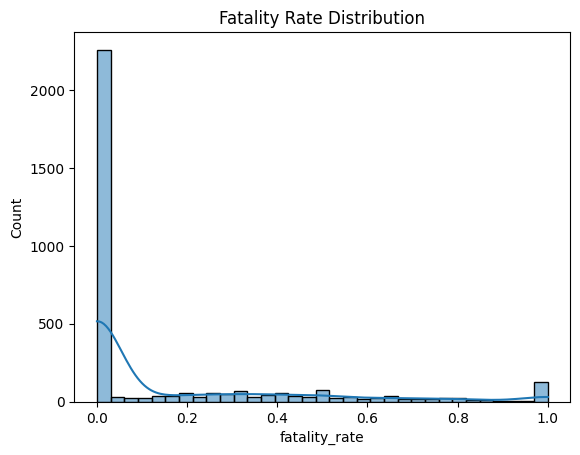

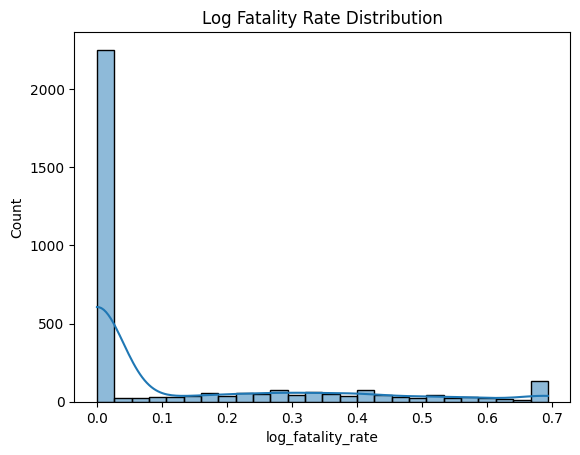

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['fatality_rate'], kde=True)
plt.title("Fatality Rate Distribution")
plt.show()

sns.histplot(df['log_fatality_rate'], kde=True)
plt.title("Log Fatality Rate Distribution")
plt.show()

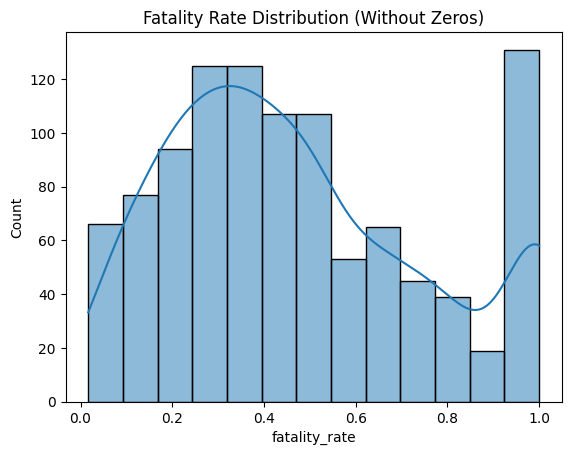

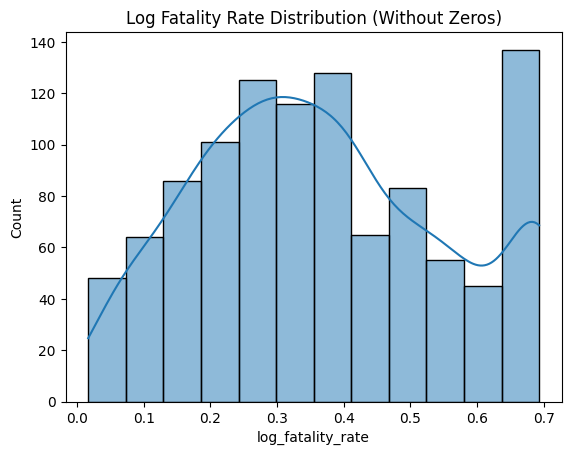

In [15]:
df_no_zero = df[df['fatality_rate'] > 0]

import seaborn as sns
import matplotlib.pyplot as plt

# Fatality Rate (no zeros)
sns.histplot(df_no_zero['fatality_rate'], kde=True)
plt.title("Fatality Rate Distribution (Without Zeros)")
plt.show()

# Log Fatality Rate (no zeros)
sns.histplot(df_no_zero['log_fatality_rate'], kde=True)
plt.title("Log Fatality Rate Distribution (Without Zeros)")
plt.show()

Right-skewed distribution → most values are low–moderate, few very high fatality cases

Major concentration (0.2–0.5) → typical events have moderate fatality rates

High-value clustering near 1 → presence of extreme lethal incidents

Non-normal data → violates OLS assumptions, suggests need for transformation

Outliers present → extreme events may bias results

Model implication → use log transformation and non-linear/robust models

Zeros removed → focuses on active events, improves distribution clarity

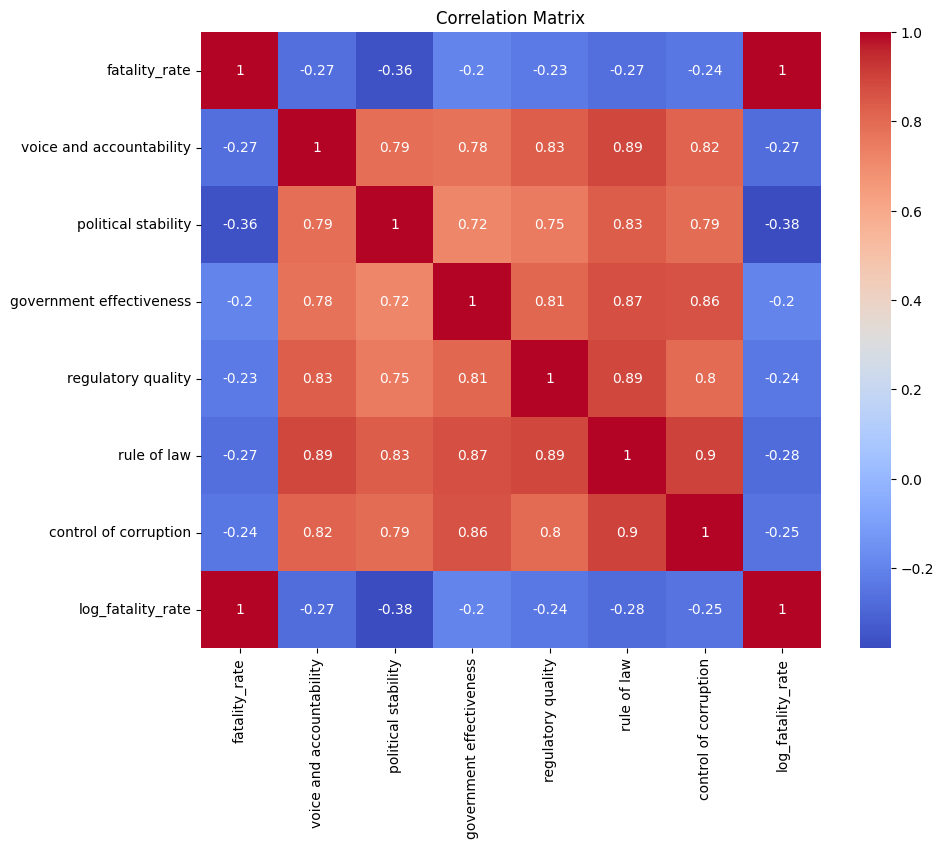

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df[cols + ['log_fatality_rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Weak–moderate negative correlation with fatality_rate (≈ -0.2 to -0.36) → better governance is associated with lower fatality rates

Strong positive correlation among WGI indicators (≈ 0.72 to 0.90) → indicators move together, reflecting overall governance quality

High multicollinearity present → variables like rule of law, regulatory quality, control of corruption are highly correlated

Political stability shows strongest negative link (~ -0.36 to -0.38) → most influential in reducing fatalities

Log transformation does not change relationships → similar correlations with log_fatality_rate

Model implication → avoid using all WGI variables together; use:

PCA / index creation, or

drop/select key variables, or

regularization (LASSO/Ridge)

Conclusion → governance matters, but effects are joint and interdependent, not isolated

<Axes: >

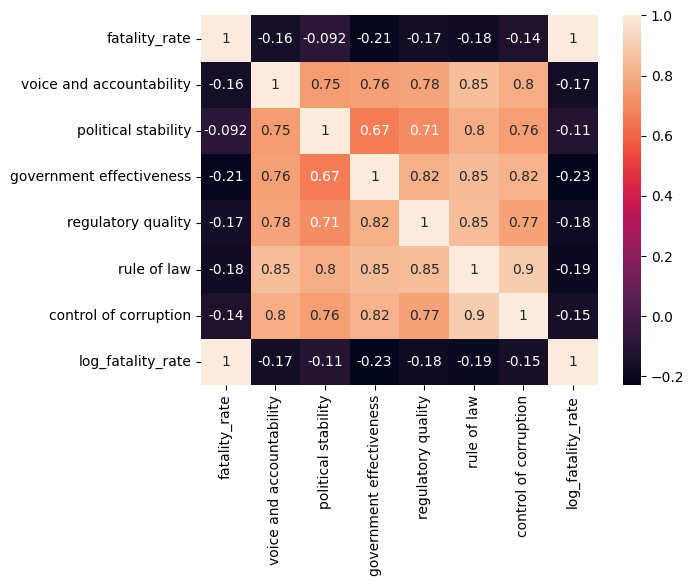

In [17]:
import seaborn as sns
sns.heatmap(df_no_zero[cols + ['log_fatality_rate']].corr(), annot=True)

INFERENTIAL ANALYSIS

In [35]:
#Normality Test
from scipy.stats import shapiro

shapiro(df['log_fatality_rate'])

ShapiroResult(statistic=np.float64(0.6391529112439116), pvalue=np.float64(4.189406893000716e-64))

Shapiro–Wilk test statistic = 0.639 → far from 1, indicating strong deviation from normality

p-value ≈ 0 (4.19e-64) → reject null hypothesis of normality at any significance level

Conclusion → fatality_rate is not normally distributed

Implication for modeling:
OLS assumptions violated
Use log transformation / robust methods / non-parametric approaches

Supports earlier finding → skewed distribution seen in histogram is statistically confirmed

In [19]:
#Normality Test
from scipy.stats import shapiro

shapiro(df_no_zero['log_fatality_rate'])

ShapiroResult(statistic=np.float64(0.958414563736066), pvalue=np.float64(9.863047911859443e-17))

In [41]:
import pandas as pd

# Create 4 quantile-based groups
df_no_zero['severity_group'] = pd.qcut(
    df_no_zero['fatality_rate'],
    q=4,
    labels=['Low', 'Moderate', 'High', 'Severe'],
    duplicates='drop'
)

# Check distribution
print(df_no_zero['severity_group'].value_counts())

print(df_no_zero.groupby('severity_group')['fatality_rate'].describe())

severity_group
High        277
Low         268
Moderate    259
Severe      249
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2543266833.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_no_zero.groupby('severity_group')['fatality_rate'].describe())


                count      mean       std       min       25%       50%  \
severity_group                                                            
Low             268.0  0.153533  0.068110  0.016746  0.094851  0.166667   
Moderate        259.0  0.337137  0.046787  0.252448  0.298441  0.333333   
High            277.0  0.532148  0.074729  0.416667  0.471698  0.506579   
Severe          249.0  0.892536  0.118616  0.667862  0.776316  0.971698   

                     75%       max  
severity_group                      
Low             0.206897  0.250000  
Moderate        0.380119  0.415842  
High            0.600000  0.666667  
Severe          1.000000  1.000000  


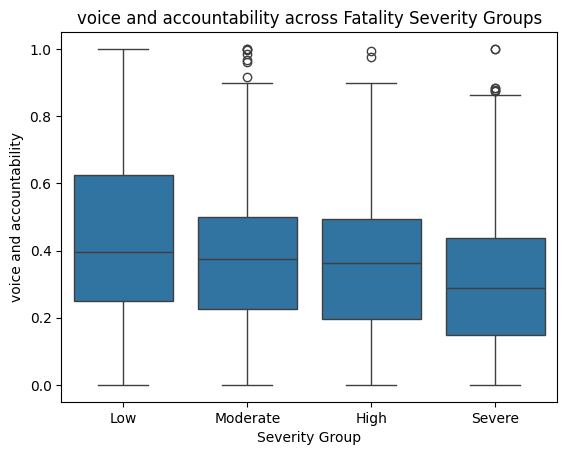

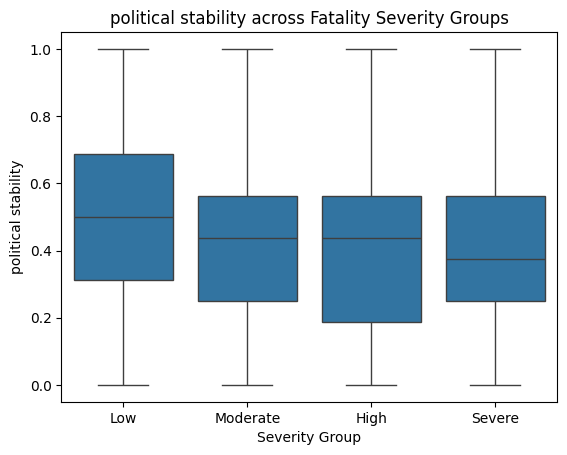

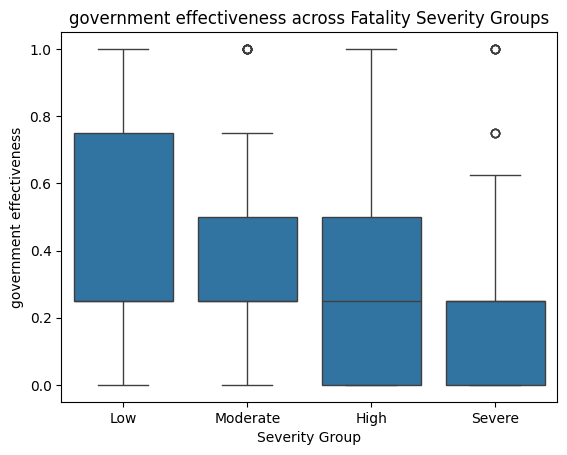

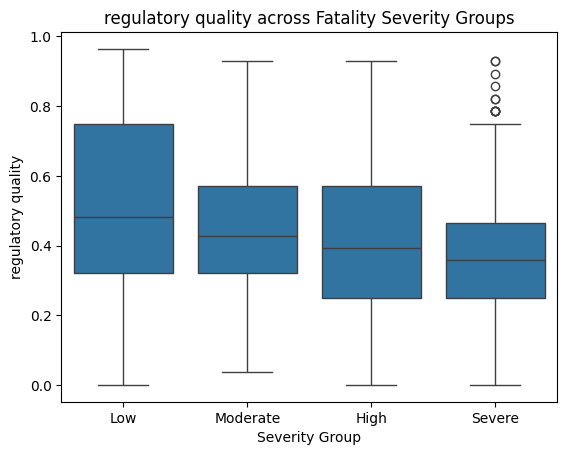

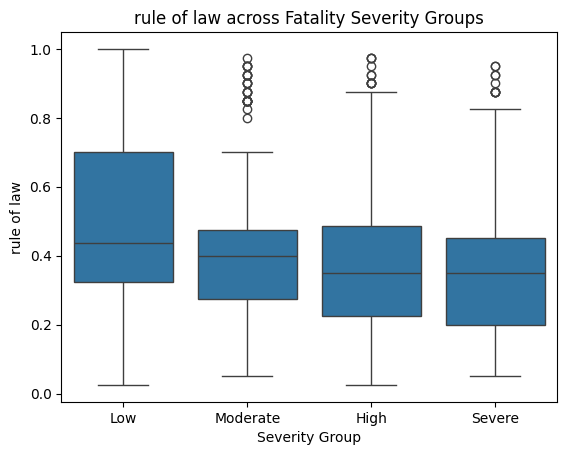

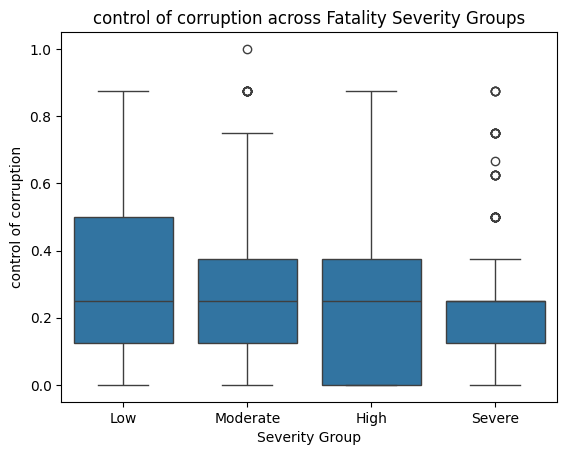

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

wgi_vars = [
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]

for var in wgi_vars:
    plt.figure()
    sns.boxplot(x='severity_group', y=var, data=df_no_zero)
    plt.title(f"{var} across Fatality Severity Groups")
    plt.xlabel("Severity Group")
    plt.ylabel(var)
    plt.show()

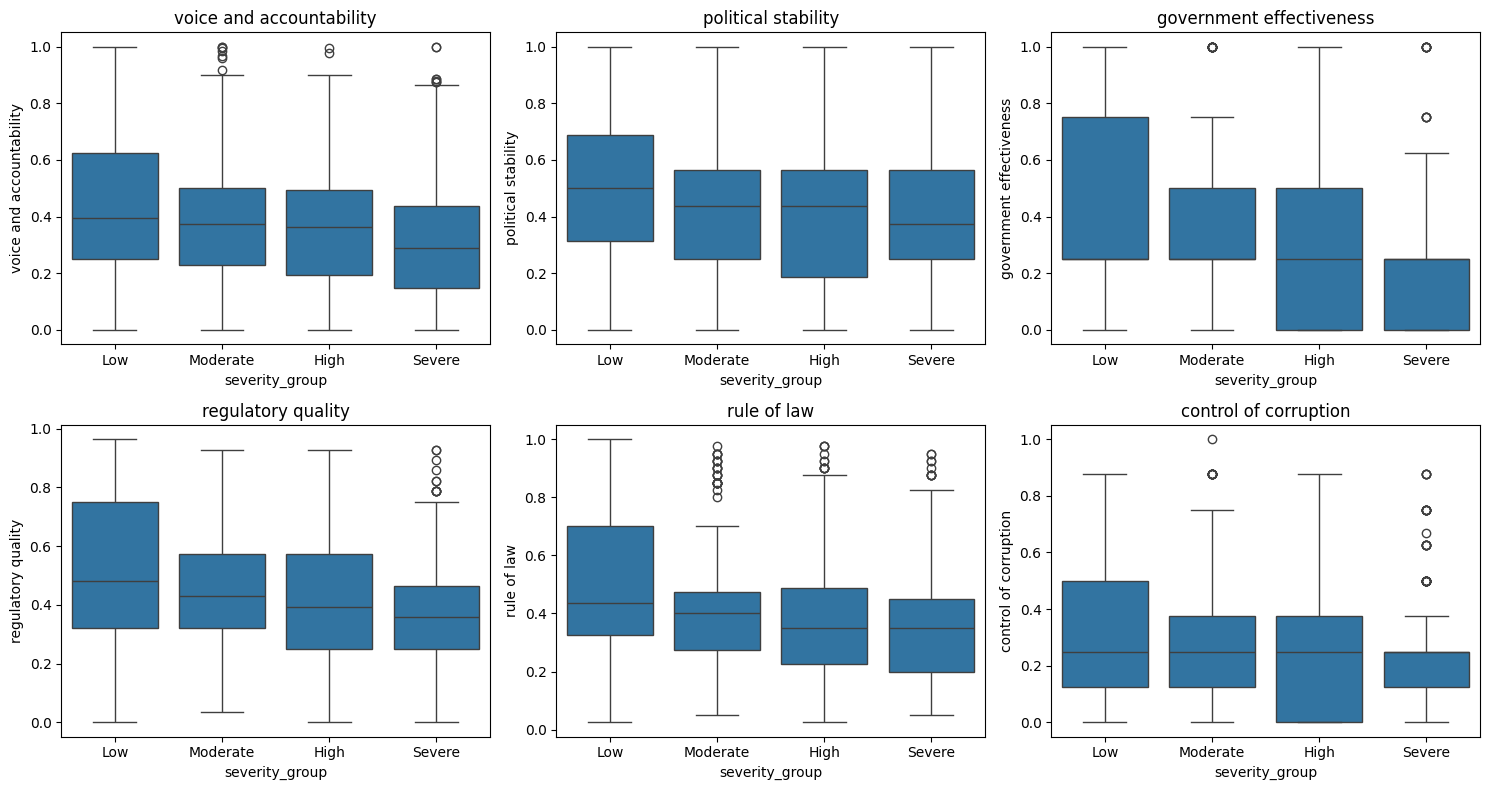

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(wgi_vars):
    ax = axes[i//3, i%3]
    sns.boxplot(x='severity_group', y=var, data=df_no_zero, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

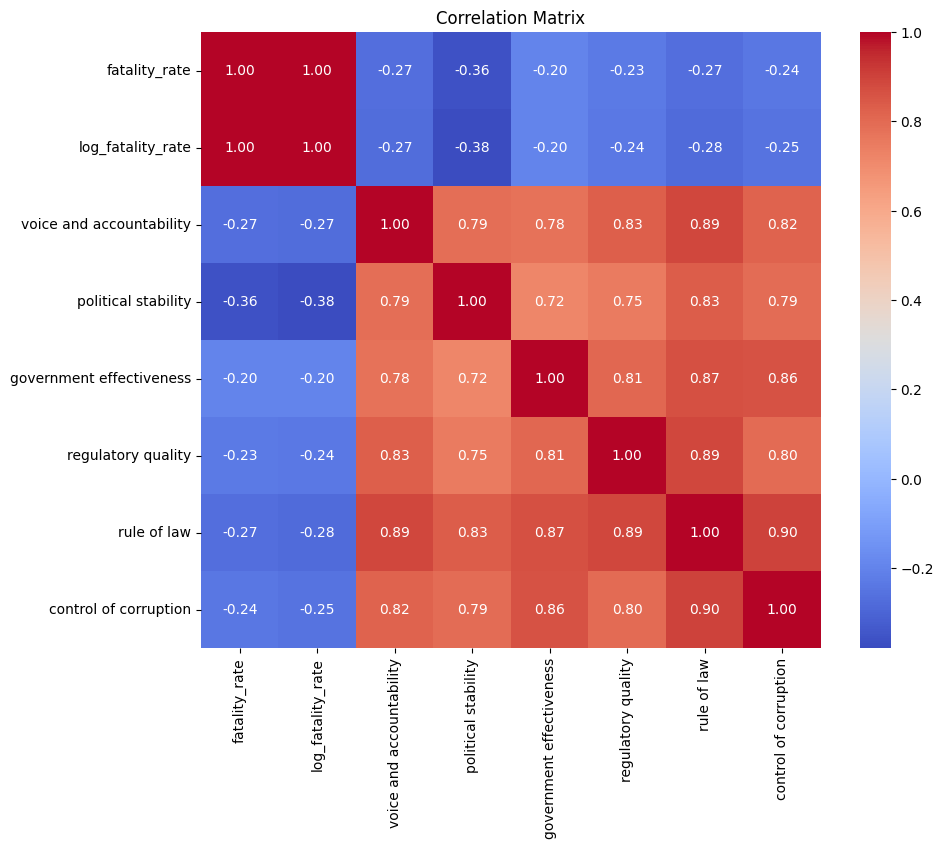

In [56]:
plt.figure(figsize=(10, 8))

corr = df[[
    'fatality_rate', 'log_fatality_rate',
    'voice and accountability', 'political stability',
    'government effectiveness', 'regulatory quality',
    'rule of law', 'control of corruption'
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

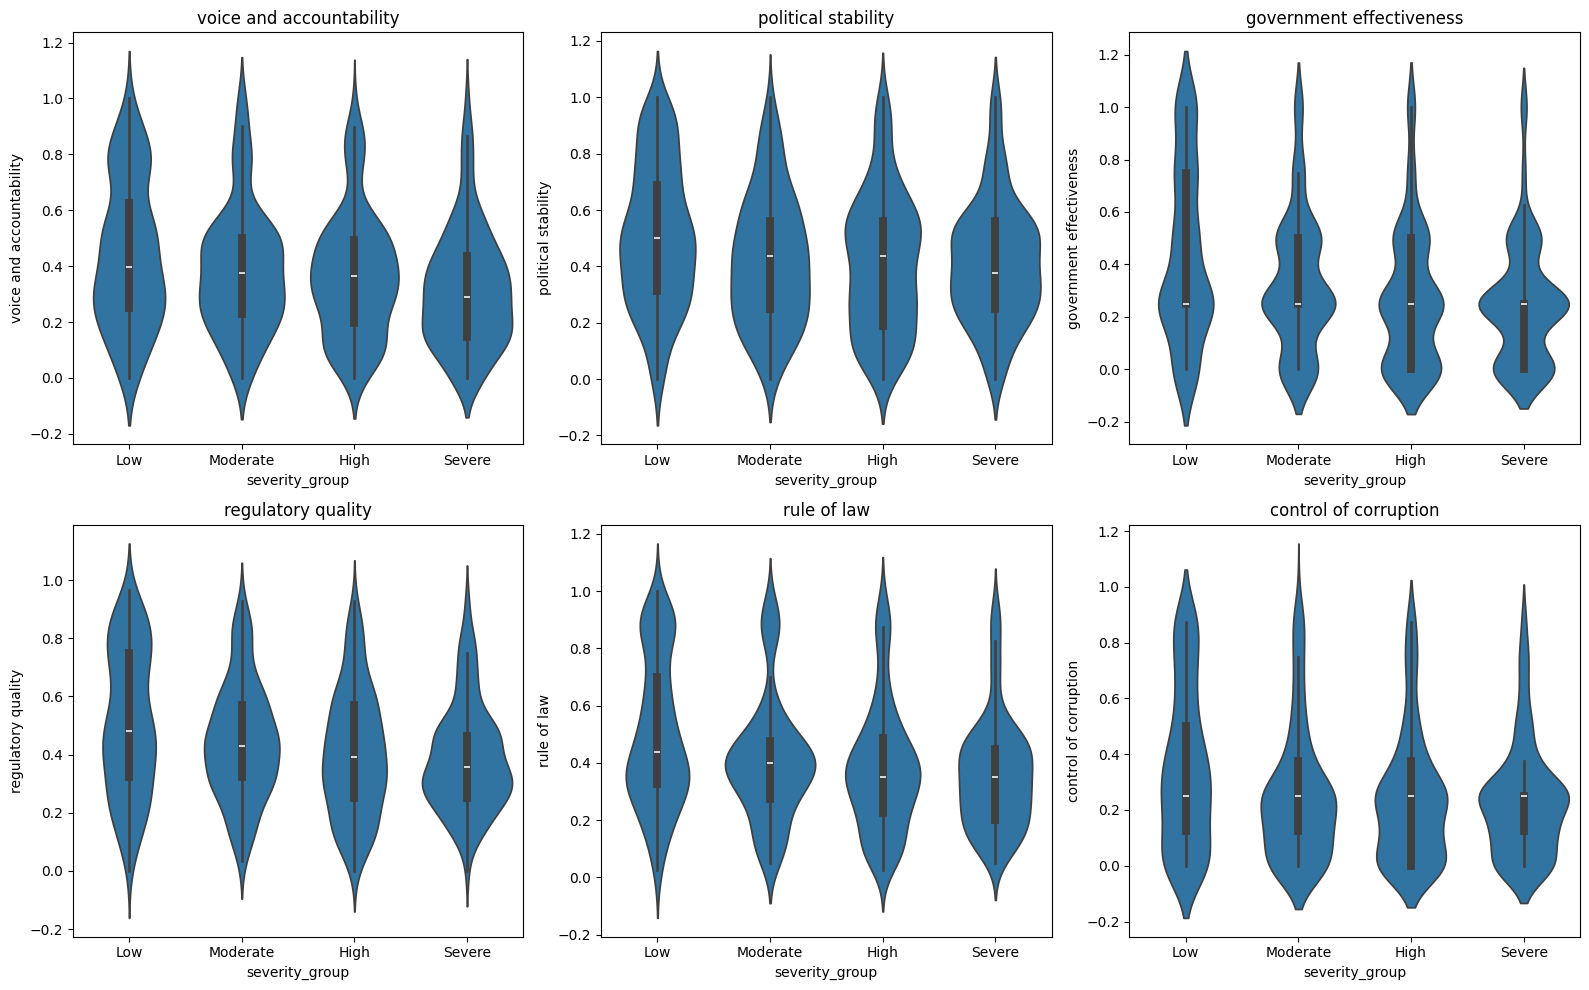

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, var in enumerate(wgi_vars):
    ax = axes[i//3, i%3]
    sns.violinplot(x='severity_group', y=var, data=df_no_zero, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2993673333.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_no_zero.groupby('severity_group')[wgi_vars].mean()


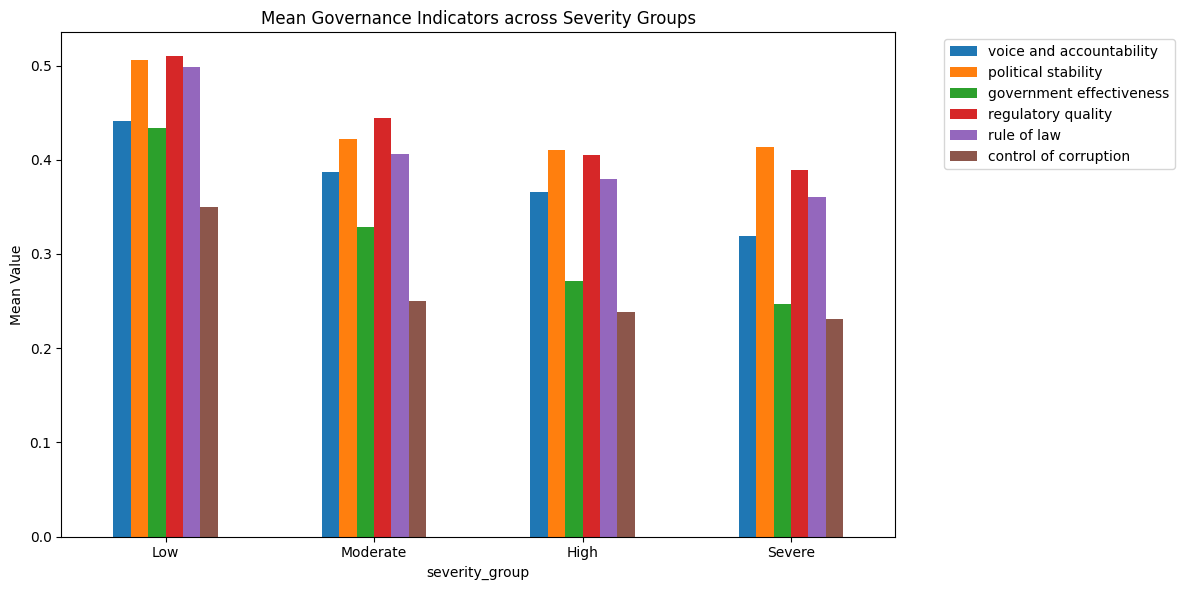

In [58]:
means = df_no_zero.groupby('severity_group')[wgi_vars].mean()

means.plot(kind='bar', figsize=(12, 6))
plt.title("Mean Governance Indicators across Severity Groups")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

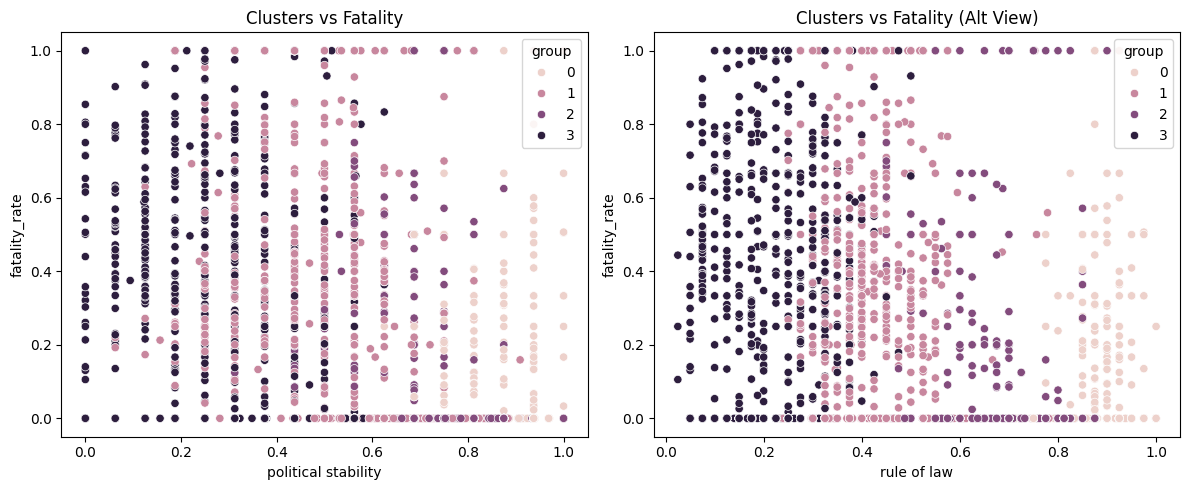

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='political stability', y='fatality_rate', hue='group', data=df, ax=axes[0])
axes[0].set_title("Clusters vs Fatality")

sns.scatterplot(x='rule of law', y='fatality_rate', hue='group', data=df, ax=axes[1])
axes[1].set_title("Clusters vs Fatality (Alt View)")

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
from scipy import stats
from scipy.stats import levene, f_oneway, kruskal

# Governance variables
wgi_vars = [
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]

# Function to format p-values
def format_p(p):
    if p < 0.001:
        return f"< 0.001 ({p:.2e})"
    else:
        return f"{p:.4f}"

for var in wgi_vars:
    print("\n" + "="*65)
    print(f"🔹 Analysis for: {var.upper()}")
    print("="*65)
    
    # Store group data
    group_data = []
    normal_flag = True
    
    # ---------------------------
    # 1. Shapiro Test
    # ---------------------------
    print("\nNormality Test (Shapiro-Wilk):")
    
    for name, group in df_no_zero.groupby('severity_group'):
        data = group[var].dropna()
        stat, p = stats.shapiro(data)
        
        if p < 0.05:
            normal_flag = False
        
        print(f"{name:<10} → p = {format_p(p)}")
        group_data.append(data)
    
    # ---------------------------
    # 2. Levene Test
    # ---------------------------
    lev_stat, lev_p = levene(*group_data)
    print(f"\nLevene Test (Equal Variance): p = {format_p(lev_p)}")
    
    # ---------------------------
    # 3. ANOVA
    # ---------------------------
    f_stat, f_p = f_oneway(*group_data)
    print(f"ANOVA Result: p = {format_p(f_p)}")
    
    # ---------------------------
    # 4. Kruskal-Wallis
    # ---------------------------
    k_stat, k_p = kruskal(*group_data)
    print(f"Kruskal-Wallis Result: p = {format_p(k_p)}")
    
    # ---------------------------
    # 5. Final Decision
    # ---------------------------
    print("\nFinal Decision:")
    
    if normal_flag and lev_p > 0.05:
        print("→ Use ANOVA (assumptions satisfied)")
    else:
        print("→ Use Kruskal-Wallis (non-parametric preferred)")
    
    # ---------------------------
    # 6. Significance Conclusion
    # ---------------------------
    if k_p < 0.05:
        print("→ Significant differences exist across severity groups")
    else:
        print("→ No significant differences across groups")


🔹 Analysis for: VOICE AND ACCOUNTABILITY

Normality Test (Shapiro-Wilk):


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\1149786037.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_no_zero.groupby('severity_group'):


Low        → p = < 0.001 (8.06e-07)
Moderate   → p = < 0.001 (1.01e-06)
High       → p = < 0.001 (3.08e-07)
Severe     → p = < 0.001 (1.12e-07)

Levene Test (Equal Variance): p = < 0.001 (7.65e-05)
ANOVA Result: p = < 0.001 (5.43e-08)
Kruskal-Wallis Result: p = < 0.001 (8.28e-07)

Final Decision:
→ Use Kruskal-Wallis (non-parametric preferred)
→ Significant differences exist across severity groups

🔹 Analysis for: POLITICAL STABILITY

Normality Test (Shapiro-Wilk):
Low        → p = < 0.001 (1.88e-05)
Moderate   → p = < 0.001 (7.14e-05)
High       → p = < 0.001 (2.87e-06)
Severe     → p = < 0.001 (9.15e-05)

Levene Test (Equal Variance): p = 0.0170
ANOVA Result: p = < 0.001 (1.92e-06)
Kruskal-Wallis Result: p = < 0.001 (1.50e-05)

Final Decision:
→ Use Kruskal-Wallis (non-parametric preferred)
→ Significant differences exist across severity groups

🔹 Analysis for: GOVERNMENT EFFECTIVENESS

Normality Test (Shapiro-Wilk):
Low        → p = < 0.001 (7.18e-14)
Moderate   → p = < 0.001 (6.72e

Normality assumption violated across all groups and variables → Shapiro–Wilk test shows p < 0.001 consistently, indicating strong non-normality

Homogeneity of variance not satisfied → Levene test significant in most cases → unequal group variances

Kruskal–Wallis test significant for all variables (p < 0.001) → confirms statistically significant differences in governance indicators across severity groups

Consistency across all WGI indicators → results are robust and not variable-specific

ANOVA also significant but less reliable → due to violation of assumptions, non-parametric results are preferred

In [65]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# Governance variables
wgi_vars = [
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]

# Function to format p-values
def format_p(p):
    if p < 0.001:
        return f"< 0.001 ({p:.2e})"
    else:
        return f"{p:.4f}"

# Store summary
results_summary = []

for var in wgi_vars:
    print("\n" + "="*70)
    print(f"🔹 INFERENCE FOR: {var.upper()}")
    print("="*70)
    
    # ---------------------------
    # 1. Prepare groups
    # ---------------------------
    grouped_data = [
        group[var].dropna().values
        for name, group in df_no_zero.groupby('severity_group')
    ]
    
    # ---------------------------
    # 2. Kruskal-Wallis Test
    # ---------------------------
    k_stat, k_p = kruskal(*grouped_data)
    
    print("\nKruskal-Wallis Test:")
    print(f"Statistic = {k_stat:.4f}")
    print(f"p-value   = {format_p(k_p)}")
    
    # ---------------------------
    # 3. Decision
    # ---------------------------
    if k_p < 0.05:
        print("→ Significant differences exist across severity groups")
        significant = True
    else:
        print("→ No significant differences across groups")
        significant = False
    
    # ---------------------------
    # 4. Dunn Post-Hoc Test
    # ---------------------------
    if significant:
        print("\nPost-hoc (Dunn Test with Bonferroni):")
        
        dunn = sp.posthoc_dunn(
            df_no_zero,
            val_col=var,
            group_col='severity_group',
            p_adjust='bonferroni'
        )
        
        # Format Dunn output
        dunn_formatted = dunn.applymap(lambda x: float(f"{x:.4e}"))
        print(dunn_formatted)
    
    # ---------------------------
    # 5. Store Summary
    # ---------------------------
    results_summary.append({
        'Variable': var,
        'Kruskal_p': k_p,
        'Significant': significant
    })

# ---------------------------
# 6. Summary Table
# ---------------------------
summary_df = pd.DataFrame(results_summary)

print("\n" + "="*70)
print("📊 FINAL SUMMARY")
print("="*70)
print(summary_df)


🔹 INFERENCE FOR: VOICE AND ACCOUNTABILITY


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_no_zero.groupby('severity_group')



Kruskal-Wallis Test:
Statistic = 31.0537
p-value   = < 0.001 (8.28e-07)
→ Significant differences exist across severity groups

Post-hoc (Dunn Test with Bonferroni):


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_formatted = dunn.applymap(lambda x: float(f"{x:.4e}"))


                   Low  Moderate      High        Severe
Low       1.000000e+00   0.22317  0.010844  2.516700e-07
Moderate  2.231700e-01   1.00000  1.000000  4.170100e-03
High      1.084400e-02   1.00000  1.000000  8.232800e-02
Severe    2.516700e-07   0.00417  0.082328  1.000000e+00

🔹 INFERENCE FOR: POLITICAL STABILITY


...


Kruskal-Wallis Test:
Statistic = 25.0545
p-value   = < 0.001 (1.50e-05)
→ Significant differences exist across severity groups

Post-hoc (Dunn Test with Bonferroni):
               Low  Moderate      High    Severe
Low       1.000000     0.001  0.000079  0.000352
Moderate  0.001000     1.000  1.000000  1.000000
High      0.000079     1.000  1.000000  1.000000
Severe    0.000352     1.000  1.000000  1.000000

🔹 INFERENCE FOR: GOVERNMENT EFFECTIVENESS


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_formatted = dunn.applymap(lambda x: float(f"{x:.4e}"))
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_no_zero.groupby('severity_group')
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_formatted = dunn.applymap(lambda x: float(f"{x:.4e}"))
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curren


Kruskal-Wallis Test:
Statistic = 54.9243
p-value   = < 0.001 (7.13e-12)
→ Significant differences exist across severity groups

Post-hoc (Dunn Test with Bonferroni):
                   Low  Moderate          High        Severe
Low       1.000000e+00  0.013479  1.510100e-08  2.438900e-10
Moderate  1.347900e-02  1.000000  2.808700e-02  2.335000e-03
High      1.510100e-08  0.028087  1.000000e+00  1.000000e+00
Severe    2.438900e-10  0.002335  1.000000e+00  1.000000e+00

🔹 INFERENCE FOR: REGULATORY QUALITY

Kruskal-Wallis Test:
Statistic = 41.0831
p-value   = < 0.001 (6.28e-09)
→ Significant differences exist across severity groups

Post-hoc (Dunn Test with Bonferroni):
                   Low  Moderate      High        Severe
Low       1.000000e+00  0.044362  0.000003  3.307000e-08
Moderate  4.436200e-02  1.000000  0.144270  9.695100e-03
High      3.436200e-06  0.144270  1.000000  1.000000e+00
Severe    3.307000e-08  0.009695  1.000000  1.000000e+00

🔹 INFERENCE FOR: RULE OF LAW


C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_formatted = dunn.applymap(lambda x: float(f"{x:.4e}"))
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_no_zero.groupby('severity_group')
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_formatted = dunn.applymap(lambda x: float(f"{x:.4e}"))
C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\541901046.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curren


Kruskal-Wallis Test:
Statistic = 44.7357
p-value   = < 0.001 (1.05e-09)
→ Significant differences exist across severity groups

Post-hoc (Dunn Test with Bonferroni):
                   Low  Moderate          High        Severe
Low       1.000000e+00  0.001727  3.216700e-07  7.695600e-09
Moderate  1.727300e-03  1.000000  4.951400e-01  8.346100e-02
High      3.216700e-07  0.495140  1.000000e+00  1.000000e+00
Severe    7.695600e-09  0.083461  1.000000e+00  1.000000e+00

🔹 INFERENCE FOR: CONTROL OF CORRUPTION

Kruskal-Wallis Test:
Statistic = 29.6154
p-value   = < 0.001 (1.66e-06)
→ Significant differences exist across severity groups

Post-hoc (Dunn Test with Bonferroni):
               Low  Moderate      High    Severe
Low       1.000000  0.000201  0.000017  0.000065
Moderate  0.000201  1.000000  1.000000  1.000000
High      0.000017  1.000000  1.000000  1.000000
Severe    0.000065  1.000000  1.000000  1.000000

📊 FINAL SUMMARY
                   Variable     Kruskal_p  Significant
0  v

In [54]:

import scikit_posthocs as sp

for var in wgi_vars:
    print("\n" + "="*60)
    print(f"Dunn Test for: {var}")
    
    dunn = sp.posthoc_dunn(
        df_no_zero,
        val_col=var,
        group_col='severity_group',
        p_adjust='bonferroni'
    )
    
    print(dunn)


Dunn Test for: voice and accountability
                   Low  Moderate      High        Severe
Low       1.000000e+00  0.223169  0.010844  2.516687e-07
Moderate  2.231690e-01  1.000000  1.000000  4.170112e-03
High      1.084404e-02  1.000000  1.000000  8.232804e-02
Severe    2.516687e-07  0.004170  0.082328  1.000000e+00

Dunn Test for: political stability
               Low  Moderate      High    Severe
Low       1.000000     0.001  0.000079  0.000352
Moderate  0.001000     1.000  1.000000  1.000000
High      0.000079     1.000  1.000000  1.000000
Severe    0.000352     1.000  1.000000  1.000000

Dunn Test for: government effectiveness
                   Low  Moderate          High        Severe
Low       1.000000e+00  0.013479  1.510057e-08  2.438881e-10
Moderate  1.347941e-02  1.000000  2.808746e-02  2.334951e-03
High      1.510057e-08  0.028087  1.000000e+00  1.000000e+00
Severe    2.438881e-10  0.002335  1.000000e+00  1.000000e+00

Dunn Test for: regulatory quality
            

Low vs High and Low vs Severe → highly significant across all variables
→ Low severity group has distinct governance levels

Low vs Moderate → sometimes significant
→ Moderate group is partially different from Low, but not always

Moderate vs High → not significant
→ These groups have similar governance characteristics

Moderate vs Severe → mostly not significant
→ No clear difference at higher severity levels

High vs Severe → not significant across variables
→ Governance does not differ within high-intensity conflict levels

Strongest effects observed in:
political stability
rule of law
control of corruption

REGRESSION ANALYSIS

In [72]:
#PREPARE DATA
import pandas as pd
import numpy as np

# Use log to reduce skewness
df_model = df_no_zero.copy()

# Define variables
y = df_model['log_fatality_rate']

X = df_model[[
    'voice and accountability',
    'political stability',
    'government effectiveness',
    'regulatory quality',
    'rule of law',
    'control of corruption'
]]

# Add constant
import statsmodels.api as sm
X = sm.add_constant(X)

#MULTICOLLINARITY
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                   Variable       VIF
0                     const  7.661103
1  voice and accountability  4.056555
2       political stability  3.059385
3  government effectiveness  4.356917
4        regulatory quality  4.270061
5               rule of law  9.662137
6     control of corruption  5.743719


In [73]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     11.52
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.64e-12
Time:                        04:56:56   Log-Likelihood:                 301.27
No. Observations:                1053   AIC:                            -588.5
Df Residuals:                    1046   BIC:                            -553.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [77]:
#HETEROSKEDASTICITY
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)

print("BP Test p-value:", bp_test[1])

robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

#WEIGHTED LEAST SQUARE
weights = 1 / (model.resid ** 2)

wls_model = sm.WLS(y, X, weights=weights).fit()
print(wls_model.summary())

BP Test p-value: 2.3750659049913183e-09
                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     12.21
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.65e-13
Time:                        05:02:32   Log-Likelihood:                 301.27
No. Observations:                1053   AIC:                            -588.5
Df Residuals:                    1046   BIC:                            -553.8
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [76]:
#AUTOCORRELATION
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model.resid)
print("Durbin-Watson:", dw)

#NORMALITY OF RESIDUALS
from scipy.stats import shapiro

stat, p = shapiro(model.resid)
print("Residual Normality p-value:", p)

#STATIONARITY
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_model['log_fatality_rate'].dropna())
print("ADF p-value:", result[1])

Durbin-Watson: 1.505748073507892
Residual Normality p-value: 2.553908039453165e-10
ADF p-value: 7.755451284765456e-12


Durbin–Watson ≈ 1.51
→ Mild positive autocorrelation (not severe, but present)

Residual normality p ≈ 0
→ Residuals not normal (expected for this data)

ADF p < 0.001
→ Series is stationary (good, no differencing needed)

So:
✔ Use robust standard errors
✔ Prefer panel / transformed models

In [82]:
df_model=df_model.reset_index()
df_model

,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate,governance_index,gov_group,governance_pca,severity_group,bin,interaction
0,afghanistan,1996,31.0,30.0,0.508197,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.410915,0.052083,Low,-3.311403,High,"(-0.001, 0.125]",0.011719
1,afghanistan,1998,8.0,30.0,0.210526,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.191055,0.052083,Low,-3.311403,Low,"(-0.001, 0.125]",0.011719
2,afghanistan,2000,38.0,11.0,0.775510,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.574088,0.052083,Low,-3.311403,Severe,"(-0.001, 0.125]",0.011719
3,afghanistan,2002,74.0,297.0,0.199461,0.187500,0.0625,0.125,0.166667,0.1875,0.125,0.181872,0.142361,Low,-2.391232,Low,"(-0.001, 0.125]",0.011719
4,afghanistan,2003,163.0,186.0,0.467049,0.250000,0.1250,0.125,0.250000,0.1875,0.125,0.383253,0.177083,Low,-2.026971,High,"(-0.001, 0.125]",0.023438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,zimbabwe,2008,7.0,8.0,0.466667,0.084333,0.3125,0.000,0.071429,0.0750,0.125,0.382992,0.111377,Low,-2.739940,High,"(-0.001, 0.125]",0.023438
1049,zimbabwe,2010,1.0,1.0,0.500000,0.088000,0.3125,0.000,0.071429,0.0750,0.125,0.405465,0.111988,Low,-2.733573,High,"(-0.001, 0.125]",0.023438
1050,zimbabwe,2013,1.0,1.0,0.500000,0.172333,0.2500,0.000,0.071429,0.1000,0.000,0.405465,0.098960,Low,-2.852262,High,"(-0.001, 0.125]",0.025000
1051,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.000,0.107143,0.1500,0.000,0.040005,0.105552,Low,-2.762923,Low,"(-0.001, 0.125]",0.028125


In [84]:
#FIXED EFFECT MODELS
import statsmodels.formula.api as smf

fe_model = smf.ols(
    'log_fatality_rate ~ Q("voice and accountability") + Q("political stability") + C(Country)',
    data=df_model
).fit()

print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     4.198
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           6.06e-38
Time:                        05:08:55   Log-Likelihood:                 512.36
No. Observations:                1053   AIC:                            -762.7
Df Residuals:                     922   BIC:                            -113.0
Df Model:                         130                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [85]:
#RANDOM EFFECT MODEL
from linearmodels.panel import RandomEffects

df_panel = df_model.set_index(['Country', 'Year'])

re_model = RandomEffects.from_formula(
    'log_fatality_rate ~ 1 + Q("political stability") + Q("rule of law")',
    data=df_panel
).fit()

print(re_model)

                        RandomEffects Estimation Summary                        
Dep. Variable:      log_fatality_rate   R-squared:                        0.1184
Estimator:              RandomEffects   R-squared (Between):             -0.0024
No. Observations:                1053   R-squared (Within):               0.0018
Date:                Fri, Mar 27 2026   R-squared (Overall):             -0.0027
Time:                        05:10:25   Log-likelihood                    446.03
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      70.482
Entities:                         129   P-value                           0.0000
Avg Obs:                       8.1628   Distribution:                  F(2,1050)
Min Obs:                       1.0000                                           
Max Obs:                       22.000   F-statistic (robust):             1.0900
                            

In [86]:
#MODEL 1: OLS (Baseline with Robust SE)
model_ols = sm.OLS(y, X).fit(cov_type='HC3')
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     12.21
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.65e-13
Time:                        05:16:15   Log-Likelihood:                 301.27
No. Observations:                1053   AIC:                            -588.5
Df Residuals:                    1046   BIC:                            -553.8
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [89]:
df_model

,Country,Year,nkill,nwound,fatality_rate,voice and accountability,political stability,government effectiveness,regulatory quality,rule of law,control of corruption,log_fatality_rate,governance_index,gov_group,governance_pca,severity_group,bin,interaction
0,afghanistan,1996,31.0,30.0,0.508197,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.410915,0.052083,Low,-3.311403,High,"(-0.001, 0.125]",0.011719
1,afghanistan,1998,8.0,30.0,0.210526,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.191055,0.052083,Low,-3.311403,Low,"(-0.001, 0.125]",0.011719
2,afghanistan,2000,38.0,11.0,0.775510,0.062500,0.0625,0.000,0.000000,0.1875,0.000,0.574088,0.052083,Low,-3.311403,Severe,"(-0.001, 0.125]",0.011719
3,afghanistan,2002,74.0,297.0,0.199461,0.187500,0.0625,0.125,0.166667,0.1875,0.125,0.181872,0.142361,Low,-2.391232,Low,"(-0.001, 0.125]",0.011719
4,afghanistan,2003,163.0,186.0,0.467049,0.250000,0.1250,0.125,0.250000,0.1875,0.125,0.383253,0.177083,Low,-2.026971,High,"(-0.001, 0.125]",0.023438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,zimbabwe,2008,7.0,8.0,0.466667,0.084333,0.3125,0.000,0.071429,0.0750,0.125,0.382992,0.111377,Low,-2.739940,High,"(-0.001, 0.125]",0.023438
1049,zimbabwe,2010,1.0,1.0,0.500000,0.088000,0.3125,0.000,0.071429,0.0750,0.125,0.405465,0.111988,Low,-2.733573,High,"(-0.001, 0.125]",0.023438
1050,zimbabwe,2013,1.0,1.0,0.500000,0.172333,0.2500,0.000,0.071429,0.1000,0.000,0.405465,0.098960,Low,-2.852262,High,"(-0.001, 0.125]",0.025000
1051,zimbabwe,2018,2.0,47.0,0.040816,0.188667,0.1875,0.000,0.107143,0.1500,0.000,0.040005,0.105552,Low,-2.762923,Low,"(-0.001, 0.125]",0.028125


In [90]:
#PCA BASED REGRESSION
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df_model['PC1'] = principal_components[:, 0]
df_model['PC2'] = principal_components[:, 1]

X_pca = df_model[['PC1', 'PC2']]
X_pca = sm.add_constant(X_pca)

model_pca = sm.OLS(y, X_pca).fit(cov_type='HC3')
print(model_pca.summary())

ValueError: The indices for endog and exog are not aligned

In [92]:
df_model = df_model.dropna().reset_index(drop=True)

y = df_model['log_fatality_rate']
X_pca = df_model[['PC1', 'PC2']]

import statsmodels.api as sm
X_pca = sm.add_constant(X_pca)

model_pca = sm.OLS(y, X_pca).fit(cov_type='HC3')
print(model_pca.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     29.49
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.47e-13
Time:                        05:31:57   Log-Likelihood:                 295.31
No. Observations:                1053   AIC:                            -584.6
Df Residuals:                    1050   BIC:                            -569.7
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3695      0.006     65.416      0.0

In [93]:
#MODEL 4: Governance Index Model
df_model['gov_index'] = df_model[features].mean(axis=1)

X_index = sm.add_constant(df_model[['gov_index']])

model_index = sm.OLS(y, X_index).fit(cov_type='HC3')
print(model_index.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     39.57
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.64e-10
Time:                        05:32:05   Log-Likelihood:                 287.23
No. Observations:                1053   AIC:                            -570.5
Df Residuals:                    1051   BIC:                            -560.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4312      0.011     39.024      0.0

In [91]:
#MODEL 5: Severity-Based Regression (Categorical)
import statsmodels.formula.api as smf

model_severity = smf.ols(
    'log_fatality_rate ~ C(severity_group)',
    data=df_model
).fit(cov_type='HC3')

print(model_severity.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     3230.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:27:10   Log-Likelihood:                 1605.7
No. Observations:                1053   AIC:                            -3203.
Df Residuals:                    1049   BIC:                            -3184.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [94]:
#INTERACTION MODEL
df_model['interaction'] = (
    df_model['political stability'] * df_model['rule of law']
)

X_interact = df_model[['political stability', 'rule of law', 'interaction']]
X_interact = sm.add_constant(X_interact)

model_interact = sm.OLS(y, X_interact).fit(cov_type='HC3')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     14.40
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.39e-09
Time:                        05:32:13   Log-Likelihood:                 290.55
No. Observations:                1053   AIC:                            -573.1
Df Residuals:                    1049   BIC:                            -553.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4098    

In [95]:
#MULTINOMIAL LOGISTIC REGRESSION
import statsmodels.api as sm

# Encode severity as numbers
df_model['severity_code'] = df_model['severity_group'].map({
    'Low': 0,
    'Moderate': 1,
    'High': 2,
    'Severe': 3
})

X = df_model[features]
X = sm.add_constant(X)

y = df_model['severity_code']

model_mnlogit = sm.MNLogit(y, X).fit()
print(model_mnlogit.summary())

Optimization terminated successfully.
         Current function value: 1.333172
         Iterations 5
                          MNLogit Regression Results                          
Dep. Variable:          severity_code   No. Observations:                 1053
Model:                        MNLogit   Df Residuals:                     1032
Method:                           MLE   Df Model:                           18
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                 0.03778
Time:                        05:36:27   Log-Likelihood:                -1403.8
converged:                       True   LL-Null:                       -1458.9
Covariance Type:            nonrobust   LLR p-value:                 2.852e-15
         severity_code=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.4713      0.258      1.826      0.068      -0.034

In [96]:
#ORDERED LOGIT
from statsmodels.miscmodels.ordinal_model import OrderedModel

y = df_model['severity_code']

X = df_model[features]

model_ord = OrderedModel(
    y,
    X,
    distr='logit'
)

result_ord = model_ord.fit(method='bfgs')
print(result_ord.summary())

Optimization terminated successfully.
         Current function value: 1.348172
         Iterations: 53
         Function evaluations: 54
         Gradient evaluations: 54
                             OrderedModel Results                             
Dep. Variable:          severity_code   Log-Likelihood:                -1419.6
Model:                   OrderedModel   AIC:                             2857.
Method:            Maximum Likelihood   BIC:                             2902.
Date:                Fri, 27 Mar 2026                                         
Time:                        05:38:11                                         
No. Observations:                1053                                         
Df Residuals:                    1044                                         
Df Model:                           6                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------

In [97]:
#PCA + ORDERED LOGIT
X_pca = df_model[['PC1', 'PC2']]

model_ord_pca = OrderedModel(
    y,
    X_pca,
    distr='logit'
)

result_ord_pca = model_ord_pca.fit(method='bfgs')
print(result_ord_pca.summary())

Optimization terminated successfully.
         Current function value: 1.353903
         Iterations: 14
         Function evaluations: 15
         Gradient evaluations: 15
                             OrderedModel Results                             
Dep. Variable:          severity_code   Log-Likelihood:                -1425.7
Model:                   OrderedModel   AIC:                             2861.
Method:            Maximum Likelihood   BIC:                             2886.
Date:                Fri, 27 Mar 2026                                         
Time:                        05:40:50                                         
No. Observations:                1053                                         
Df Residuals:                    1048                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [98]:
#GOVERNANCE INDEX + OREDER LOGIT
X_index = df_model[['gov_index']]

model_ord_index = OrderedModel(
    y,
    X_index,
    distr='logit'
)

result_ord_index = model_ord_index.fit(method='bfgs')
print(result_ord_index.summary())

Optimization terminated successfully.
         Current function value: 1.361791
         Iterations: 14
         Function evaluations: 16
         Gradient evaluations: 16
                             OrderedModel Results                             
Dep. Variable:          severity_code   Log-Likelihood:                -1434.0
Model:                   OrderedModel   AIC:                             2876.
Method:            Maximum Likelihood   BIC:                             2896.
Date:                Fri, 27 Mar 2026                                         
Time:                        05:42:11                                         
No. Observations:                1053                                         
Df Residuals:                    1049                                         
Df Model:                           1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [105]:
import pandas as pd
from scipy.stats import chi2

# ------------------------------
# 2. Pseudo R-squared (McFadden)
llf = result_ord_index.llf
llnull = result_ord_index.llnull
pseudo_r2 = 1 - (llf / llnull)
print(f"\nPseudo R² (McFadden): {pseudo_r2:.3f}")

# ------------------------------
# 3. Likelihood Ratio Test (model vs null)
lr_stat = -2 * (llnull - llf)
p_value = chi2.sf(lr_stat, df=result_ord_index.df_model)
print(f"LR chi2 = {lr_stat:.2f}, p-value = {p_value:.10f}")

# 2. Standard Ordered Logit summary with generalized p-values
pvals = result_ord_index.pvalues
pvals_generalized = [f"<0.001" if p < 0.001 else f"{p:.3f}" for p in pvals]

summary_df = pd.DataFrame({
    'coef': result_ord_index.params,
    'std err': result_ord_index.bse,
    'z': result_ord_index.tvalues,
    'P>|z|': pvals_generalized
})
print("Ordered Logit Coefficients:")
print(summary_df)

# ------------------------------
# 4. Predicted probabilities for low, median, high gov_index
gov_vals = pd.DataFrame({
    'gov_index': [df_model['gov_index'].min(),
                  df_model['gov_index'].median(),
                  df_model['gov_index'].max()]
})

pred_probs = result_ord_index.model.predict(result_ord_index.params, exog=gov_vals)
pred_probs_df = pd.DataFrame(pred_probs, columns=[f"Severity_{i}" for i in range(pred_probs.shape[1])])
pred_probs_df['gov_index'] = gov_vals['gov_index']
print("\nPredicted probabilities by gov_index:")
print(pred_probs_df)


Pseudo R² (McFadden): 0.017
LR chi2 = 49.96, p-value = 0.0000000000
Ordered Logit Coefficients:
               coef   std err          z   P>|z|
gov_index -1.828381  0.261859  -6.982316  <0.001
0/1       -1.790481  0.126472 -14.157170  <0.001
1/2        0.113048  0.056737   1.992475   0.046
2/3        0.184149  0.054568   3.374684  <0.001

Predicted probabilities by gov_index:
   Severity_0  Severity_1  Severity_2  Severity_3  gov_index
0    0.145296    0.197176    0.291640    0.365887   0.010119
1    0.235162    0.249916    0.273058    0.241863   0.334226
2    0.494511    0.255323    0.159037    0.091129   0.967262


In [23]:
#OLS regression
import statsmodels.api as sm

X = df[['voice and accountability', 'political stability',
        'government effectiveness', 'regulatory quality',
        'rule of law', 'control of corruption']]

X = sm.add_constant(X)
y = df['log_fatality_rate']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     100.9
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          6.97e-117
Time:                        03:17:31   Log-Likelihood:                 871.68
No. Observations:                3303   AIC:                            -1729.
Df Residuals:                    3296   BIC:                            -1687.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [30]:
#PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = df_no_zero[['voice and accountability', 'political stability',
               'government effectiveness', 'regulatory quality',
               'rule of law', 'control of corruption']]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=1)
df_no_zero['governance_pca'] = pca.fit_transform(scaled)

X_pca = sm.add_constant(df_no_zero['governance_pca'])
model_pca = sm.OLS(y, X_pca).fit()
print(model_pca.summary())

C:\Users\DELL\AppData\Local\Temp\ipykernel_60204\2105881132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_zero['governance_pca'] = pca.fit_transform(scaled)


                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     39.54
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.70e-10
Time:                        03:20:09   Log-Likelihood:                 287.03
No. Observations:                1053   AIC:                            -570.1
Df Residuals:                    1051   BIC:                            -560.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3695      0.006     65.

PANEL DATA ANALYSIS (VERY IMPORTANT 🔥)

In [31]:
#Fixed Effects Model
from linearmodels.panel import PanelOLS

df_no_zero = df_no_zero.set_index(['Country', 'Year'])

X = df_no_zero[['governance_pca']]
y = df_no_zero['log_fatality_rate']

model_fe = PanelOLS(y, X, entity_effects=True)
fe_res = model_fe.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:      log_fatality_rate   R-squared:                        0.0028
Estimator:                   PanelOLS   R-squared (Between):              0.0219
No. Observations:                1053   R-squared (Within):               0.0028
Date:                Fri, Mar 27 2026   R-squared (Overall):             -0.0187
Time:                        03:21:08   Log-likelihood                    512.52
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2.6105
Entities:                         129   P-value                           0.1065
Avg Obs:                       8.1628   Distribution:                   F(1,923)
Min Obs:                       1.0000                                           
Max Obs:                       22.000   F-statistic (robust):             2.6105
                            

In [32]:
#Random Effects Model
from linearmodels.panel import RandomEffects

model_re = RandomEffects(y, X)
re_res = model_re.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:      log_fatality_rate   R-squared:                        0.0052
Estimator:              RandomEffects   R-squared (Between):              0.0253
No. Observations:                1053   R-squared (Within):               0.0026
Date:                Fri, Mar 27 2026   R-squared (Overall):             -0.0252
Time:                        03:21:18   Log-likelihood                    443.84
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5.4864
Entities:                         129   P-value                           0.0194
Avg Obs:                       8.1628   Distribution:                  F(1,1052)
Min Obs:                       1.0000                                           
Max Obs:                       22.000   F-statistic (robust):             5.4864
                            

In [33]:
#Hausman Test
from linearmodels.panel import compare

compare({'FE': fe_res, 'RE': re_res})

,FE,RE
Dep. Variable,log_fatality_rate,log_fatality_rate
Estimator,PanelOLS,RandomEffects
No. Observations,1053,1053
Cov. Est.,Unadjusted,Unadjusted
R-squared,0.0028,0.0052
R-Squared (Within),0.0028,0.0026
R-Squared (Between),0.0219,0.0253
R-Squared (Overall),-0.0187,-0.0252
F-statistic,2.6105,5.4864
P-value (F-stat),0.1065,0.0194
